# Neurosignature Analysis: Simple CTRNN

Walks through the full analysis pipeline:
- 16 hidden units, 3 inputs, 4 outputs
- Poisson event streams (TsGroup) as inputs
- CTRNN with embedded alpha-function synaptic kernel
- Simulator as a thin callable wrapper
- VectorDescriptor built from ScalarDescriptor components
- Experiment running multiple trials and collecting descriptor vectors

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurosignature as ns

np.random.seed(0)
sns.set_context("notebook")
plt.rcParams["axes.formatter.useoffset"] = False

## 1. Model Setup

Build weight matrices and instantiate the CTRNN.
`tau_syn_ms` controls the synaptic kernel decay embedded in the system.
`dt_ms` is the Euler integration step.

In [2]:
n_hidden = 16
n_inputs = 3
n_outputs = 4
dt_ms = 1.0

rng = np.random.default_rng(0)

W_int = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_prop = ns.generate_random_matrix(
    n_hidden, n_hidden, dist="normal", matrix_type="symmetric"
)
W_u = ns.relu(
    ns.generate_random_matrix(n_hidden, n_inputs, dist="normal", matrix_type="dense")
)
W_o = ns.relu(
    ns.generate_random_matrix(n_outputs, n_hidden, dist="normal", matrix_type="dense")
)

system = ns.ContinuousTimeRNN(
    n_hidden=n_hidden,
    n_inputs=n_inputs,
    n_outputs=n_outputs,
    W_int=W_int,
    W_prop=W_prop,
    W_u=W_u,
    W_o=W_o,
    g=0.05,
    tau=5.0,
    V_rest=-65.0,
    polarity="excitatory",
    phi="tanh",
    tau_syn_ms=5.0,
    dt_ms=dt_ms,
)

print(system)

## 2. Single Trial: Generate Inputs & Run Simulation

`InputGenerator.generate()` returns a `TsGroup` of Poisson spike trains.
`Simulator` wraps the CTRNN `__call__` method, which converts the event
streams to smooth currents internally and runs Euler integration.

In [3]:
input_gen = ns.InputGenerator(
    n_channels=n_inputs,
    rate_hz=50.0,
    dt_ms=dt_ms,
    seed=42,
)

duration_ms = 500.0
ts_group = input_gen.generate(duration_ms=duration_ms)

simulator = ns.Simulator(system)
outputs = simulator.run(ts_group)

time_ms = np.asarray(outputs.index) * 1000.0  # pynapple stores seconds
outputs_arr = np.asarray(outputs)

print(f"Input channels : {len(ts_group)}")
print(f"Outputs shape  : {outputs.shape}")
print(f"Output range   : [{outputs_arr.min():.3f}, {outputs_arr.max():.3f}] mV")

Input channels : 3
Outputs shape  : (500, 4)
Output range   : [-65.000, -55.352] mV


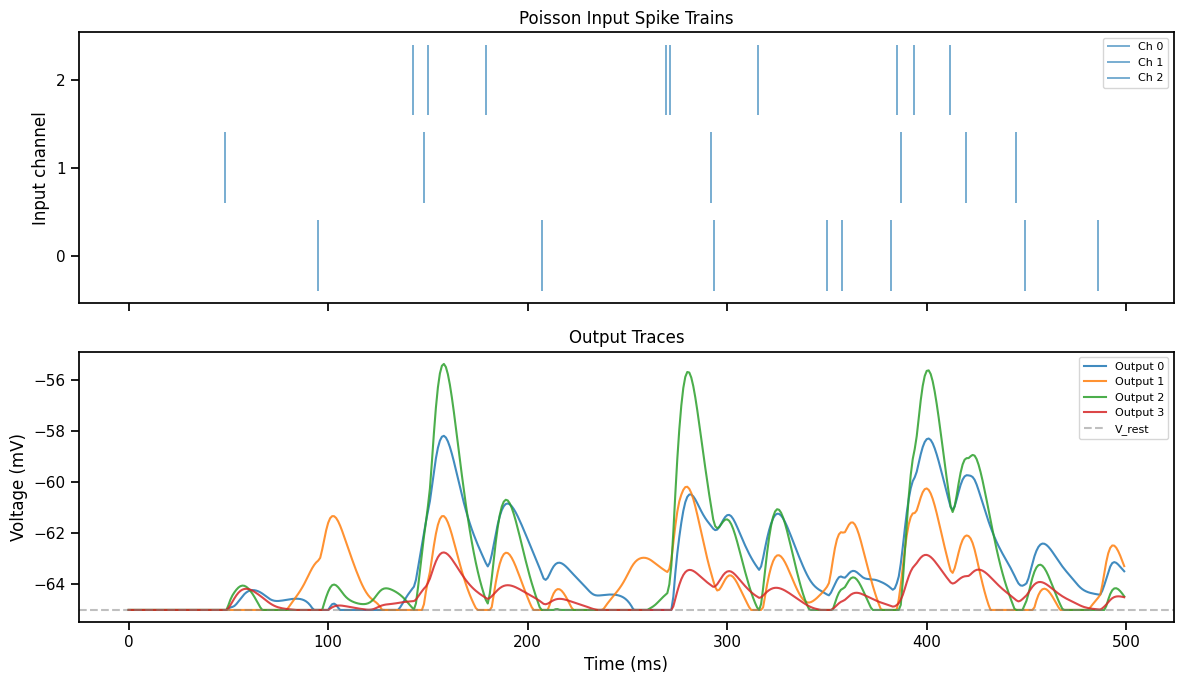

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax = axes[0]
for key in sorted(ts_group.keys()):
    spike_times_ms = ts_group[key].index * 1000.0
    ax.vlines(
        spike_times_ms,
        key - 0.4,
        key + 0.4,
        linewidth=1.2,
        alpha=0.7,
        label=f"Ch {key}",
    )
ax.set_ylabel("Input channel")
ax.set_title("Poisson Input Spike Trains")
ax.set_yticks(sorted(ts_group.keys()))
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
for i in range(n_outputs):
    ax.plot(time_ms, outputs_arr[:, i], label=f"Output {i}", alpha=0.85)
ax.axhline(system.V_rest, color="gray", linestyle="--", alpha=0.5, label="V_rest")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Voltage (mV)")
ax.set_title("Output Traces")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Vector Descriptor

Every `ScalarDescriptor` returns a **single float** summarising the full
output `TsdFrame`.  A reference channel `v_ref = V[:, reference_channel]`
is extracted by `VectorDescriptor` and passed to each descriptor.
Residuals `R_i = V_i - v_ref` capture latent dynamics relative to the
physical output.

In [5]:
reference_channel = 0

descriptor_components = [
    ns.ReferenceStd(),
    ns.ReferenceSpectralCentroid(dt_ms=dt_ms),
    ns.ResidualMean(),
    ns.ResidualStd(),
    ns.ResidualEnergy(dt_ms=dt_ms),
    ns.ResidualSpectralCentroidMean(dt_ms=dt_ms),
    ns.ResidualSpectralCentroidStd(dt_ms=dt_ms),
    ns.ResidualParticipationRatio(),
    ns.ResidualMaxEigenvalue(),
    ns.ResidualEigenvalueEntropy(),
    ns.CrossCorrelationMean(),
    ns.TransmissionEfficiency(),
]

vd = ns.VectorDescriptor(descriptor_components, reference_channel=reference_channel)
component_labels = vd.labels()
single_desc = vd.compute(outputs)

print(f"Descriptor dimension: {len(single_desc)}")
for label, val in zip(component_labels, single_desc):
    print(f"  {label:16s}: {val:.4f}")

Descriptor dimension: 12
  ref_std         : 0.5792
  ref_SC          : 2.4392
  resid_mean      : -0.6657
  resid_std       : 0.2608
  resid_energy    : 8.1760
  resid_SC_mean   : 2.5361
  resid_SC_std    : 1.2138
  part_ratio      : 0.5802
  max_eigval      : 1.6222
  eigval_entropy  : 0.7593
  xcorr_mean      : 0.7696
  trans_eff       : -0.4733


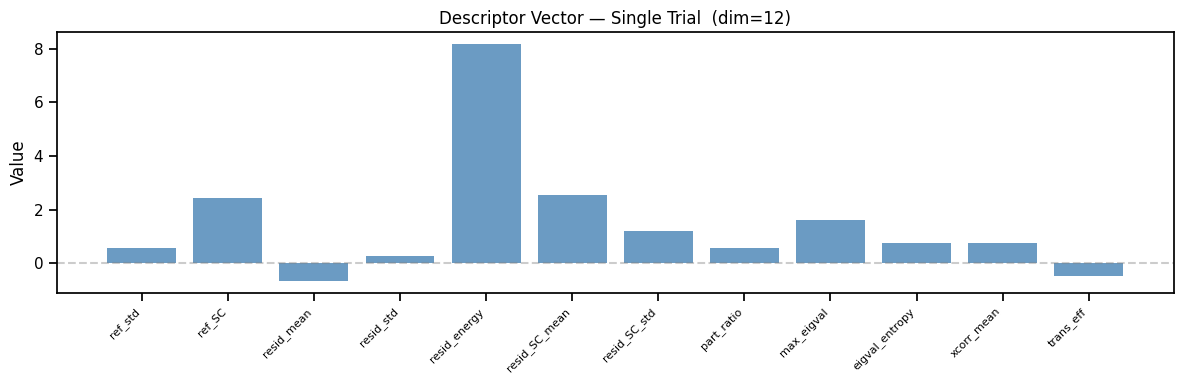

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(single_desc)), single_desc, alpha=0.8, color="steelblue")
ax.set_xticks(range(len(single_desc)))
ax.set_xticklabels(component_labels, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_ylabel("Value")
ax.set_title(f"Descriptor Vector — Single Trial  (dim={len(single_desc)})")
plt.tight_layout()
plt.show()

## 4. Experiment: Multiple Trials

`Experiment` loops over `n_trials` independent Poisson input realisations,
runs the simulator, and collects one descriptor vector per trial.
The result is a `(n_trials, descriptor_dim)` numpy array.

In [7]:
n_trials = 20

experiment = ns.Experiment(
    input_gen=input_gen,
    simulator=simulator,
    descriptor=vd,
)

descriptor_matrix = experiment.run(n_trials=n_trials, duration_ms=duration_ms)
normed_matrix, desc_mean, desc_std = experiment.normalize(descriptor_matrix)

print(f"Descriptor matrix shape: {descriptor_matrix.shape}")
print(f"Per-component mean  : {desc_mean.round(3)}")
print(f"Per-component std   : {desc_std.round(3)}")

Descriptor matrix shape: (20, 12)
Per-component mean  : [ 0.43   2.586 -0.598  0.126  7.938  2.66   0.778  0.614  1.357  0.789
  0.707 -0.515]
Per-component std   : [0.199 0.152 0.168 0.099 0.266 0.071 0.837 0.107 0.305 0.08  0.122 0.249]


### 4a. Raw descriptor variability across trials

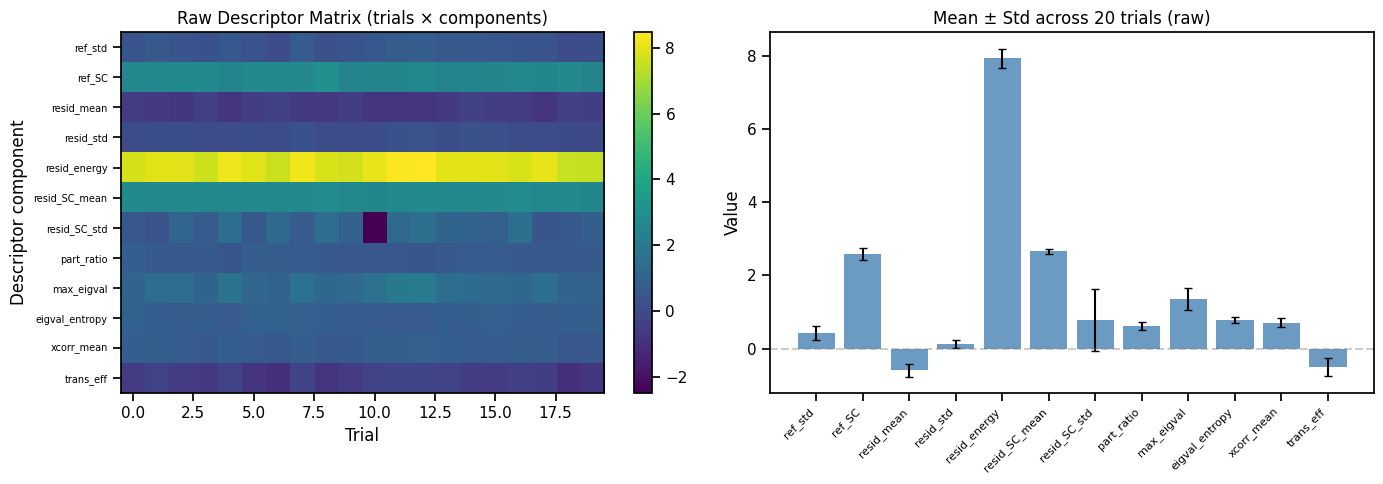

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(descriptor_matrix.T, aspect="auto", cmap="viridis")
ax.set_xlabel("Trial")
ax.set_ylabel("Descriptor component")
ax.set_yticks(range(len(component_labels)))
ax.set_yticklabels(component_labels, fontsize=7)
ax.set_title("Raw Descriptor Matrix (trials × components)")
plt.colorbar(im, ax=ax)

ax = axes[1]
x = np.arange(len(desc_mean))
ax.bar(
    x, desc_mean, yerr=desc_std, capsize=3, alpha=0.8, color="steelblue", ecolor="black"
)
ax.set_xticks(x)
ax.set_xticklabels(component_labels, rotation=45, ha="right", fontsize=8)
ax.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax.set_ylabel("Value")
ax.set_title(f"Mean ± Std across {n_trials} trials (raw)")

plt.tight_layout()
plt.show()